In [1]:
!pip install -U inference-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: opencv-python
    Found exis

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Detected lids: 4
Lid 0: Ellipse=81.3 | PCA=72.1 | Chosen=81.3 | ELLIPSE | diff=9.22
Lid 1: Ellipse=49.3 | PCA=27.8 | Chosen=27.8 | PCA | diff=21.49
Lid 2: Ellipse=352.4 | PCA=347.7 | Chosen=352.4 | ELLIPSE | diff=4.67
Lid 3: Ellipse=133.6 | PCA=125.8 | Chosen=133.6 | ELLIPSE | diff=7.80


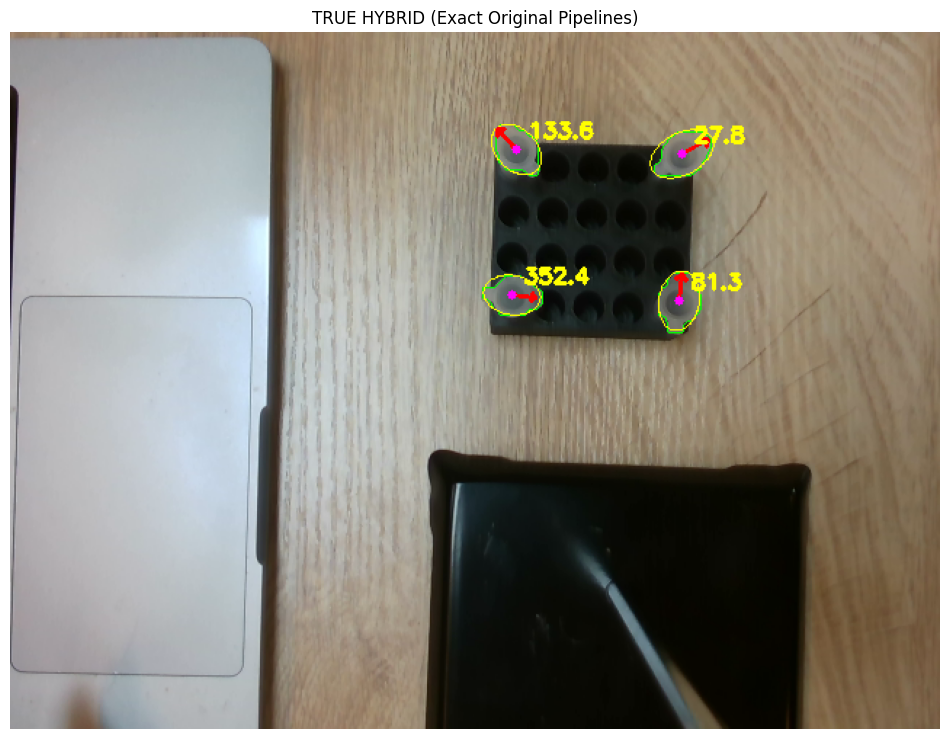

In [2]:
#@title True Hybrid
# ============================================================
# TRUE HYBRID (FINAL CORRECT VERSION)
#
# CRITICAL DESIGN:
# - Runs ORIGINAL ellipse pipeline independently
# - Runs ORIGINAL PCA pipeline independently
# - Compares FINAL orientation vectors ONLY
# - Chooses one final result
#
# NO shared geometry logic.
# NO reconstructed PCA/ellipse internals.
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from inference_sdk import InferenceHTTPClient

# ============================================================
# CONFIG
# ============================================================

API_KEY = "vof93SgrEEFl6QUIp6BI"

SEGMENTATION_MODEL_ID = "zeon-9tvbv/1"
KEYPOINT_MODEL_ID = "zeon-2/2"

IMAGE_PATH = "/content/drive/MyDrive/images/043033e6-color.png"

PADDING = 15

ANGLE_THRESHOLD = 10

# ============================================================
# INITIALIZE CLIENT
# ============================================================

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

# ============================================================
# LOAD IMAGE
# ============================================================

image = cv2.imread(IMAGE_PATH)

orig = image.copy()

# ============================================================
# RUN SEGMENTATION MODEL
# ============================================================

result = CLIENT.infer(
    IMAGE_PATH,
    model_id=SEGMENTATION_MODEL_ID
)

predictions = result["predictions"]

print(f"\nDetected lids: {len(predictions)}")

# ============================================================
# PROCESS EACH LID
# ============================================================

for idx, pred in enumerate(predictions):

    try:

        # ====================================================
        # CONTOUR
        # ====================================================

        points = pred["points"]

        contour = np.array(
            [[int(p["x"]), int(p["y"])] for p in points],
            dtype=np.int32
        )

        if len(contour) < 5:
            continue

        # ====================================================
        # PCA SMOOTHING
        # (ONLY PCA VERSION USED THIS)
        # ====================================================

        contour_pca = cv2.convexHull(contour)

        epsilon = 0.01 * cv2.arcLength(
            contour_pca,
            True
        )

        contour_pca = cv2.approxPolyDP(
            contour_pca,
            epsilon,
            True
        )

        # ====================================================
        # ELLIPSE FIT
        # ====================================================

        ellipse = cv2.fitEllipse(contour)

        (cx, cy), (axis1, axis2), raw_angle = ellipse

        cx = int(cx)
        cy = int(cy)

        # ====================================================
        # ELLIPSE PIPELINE
        # EXACT ORIGINAL LOGIC
        # ====================================================

        if axis1 >= axis2:

            ellipse_major_axis = axis1
            ellipse_minor_axis = axis2
            ellipse_major_angle = raw_angle

        else:

            ellipse_major_axis = axis2
            ellipse_minor_axis = axis1
            ellipse_major_angle = raw_angle + 90

        ellipse_major_angle = (
            ellipse_major_angle % 360
        )

        # ORIGINAL ellipse vector
        theta_e = np.deg2rad(
            ellipse_major_angle
        )

        ellipse_axis_vec = np.array([
            np.cos(theta_e),
            -np.sin(theta_e)
        ])

        # ====================================================
        # PCA PIPELINE
        # EXACT ORIGINAL LOGIC
        # ====================================================

        pts = contour_pca.reshape(
            -1,
            2
        ).astype(np.float32)

        mean, eigenvectors = cv2.PCACompute(
            pts,
            mean=None
        )

        principal_vec = eigenvectors[0]

        vx = principal_vec[0]
        vy = principal_vec[1]

        # EXACT original correction
        vy = -vy

        pca_major_angle = np.degrees(
            np.arctan2(vy, vx)
        )

        pca_major_angle = (
            pca_major_angle % 360
        )

        # ORIGINAL PCA vector
        theta_p = np.deg2rad(
            pca_major_angle
        )

        pca_axis_vec = np.array([
            np.cos(theta_p),
            np.sin(theta_p)
        ])

        # ====================================================
        # CREATE CROP
        # ====================================================

        x, y, w, h = cv2.boundingRect(
            contour
        )

        x1 = max(0, x - PADDING)
        y1 = max(0, y - PADDING)

        x2 = min(
            image.shape[1],
            x + w + PADDING
        )

        y2 = min(
            image.shape[0],
            y + h + PADDING
        )

        crop = image[
            y1:y2,
            x1:x2
        ]

        crop_path = (
            f"/content/temp_crop_{idx}.jpg"
        )

        cv2.imwrite(
            crop_path,
            crop
        )

        # ====================================================
        # KEYPOINT MODEL
        # ====================================================

        kp_result = CLIENT.infer(
            crop_path,
            model_id=KEYPOINT_MODEL_ID
        )

        kp_predictions = (
            kp_result["predictions"]
        )

        if len(kp_predictions) == 0:
            continue

        kp = kp_predictions[0]

        keypoints = kp["keypoints"]

        hinge = None
        tab = None

        # ====================================================
        # EXTRACT KEYPOINTS
        # ====================================================

        for k in keypoints:

            cls = k["class"].lower()

            px = k["x"] + x1
            py = k["y"] + y1

            if "hinge" in cls:

                hinge = np.array([px, py])

            elif "tab" in cls:

                tab = np.array([px, py])

        if hinge is None or tab is None:
            continue

        # ====================================================
        # KEYPOINT VECTOR
        # ====================================================

        kp_vec = tab - hinge

        kp_norm = np.linalg.norm(
            kp_vec
        )

        if kp_norm < 1e-6:
            continue

        kp_vec = kp_vec / kp_norm

        # EXACT original correction
        kp_vec[1] *= -1

        # ====================================================
        # ORIGINAL ELLIPSE DIRECTION RESOLUTION
        # ====================================================

        ellipse_axis_vec_1 = ellipse_axis_vec
        ellipse_axis_vec_2 = -ellipse_axis_vec

        dot1 = np.dot(
            ellipse_axis_vec_1,
            kp_vec
        )

        dot2 = np.dot(
            ellipse_axis_vec_2,
            kp_vec
        )

        if dot1 >= dot2:

            ellipse_final_vec = (
                ellipse_axis_vec_1
            )

        else:

            ellipse_final_vec = (
                ellipse_axis_vec_2
            )

        # FINAL ellipse angle
        ellipse_true_angle = np.degrees(
            np.arctan2(
                -ellipse_final_vec[1],
                ellipse_final_vec[0]
            )
        )

        ellipse_true_angle = (
            ellipse_true_angle % 360
        )

        ellipse_true_angle = (
            360 - ellipse_true_angle
        ) % 360

        # ====================================================
        # ORIGINAL PCA DIRECTION RESOLUTION
        # ====================================================

        pca_axis_vec_1 = pca_axis_vec
        pca_axis_vec_2 = -pca_axis_vec

        dot1 = np.dot(
            pca_axis_vec_1,
            kp_vec
        )

        dot2 = np.dot(
            pca_axis_vec_2,
            kp_vec
        )

        if dot1 >= dot2:

            pca_final_vec = (
                pca_axis_vec_1
            )

        else:

            pca_final_vec = (
                pca_axis_vec_2
            )

        # FINAL PCA angle
        pca_true_angle = np.degrees(
            np.arctan2(
                pca_final_vec[1],
                pca_final_vec[0]
            )
        )

        pca_true_angle = (
            pca_true_angle % 360
        )

        # ====================================================
        # TRUE GEOMETRIC DISAGREEMENT
        # Compare FINAL outputs ONLY
        # ====================================================

        dot = np.dot(
            ellipse_final_vec,
            pca_final_vec
        )

        dot = np.clip(dot, -1, 1)

        dot = abs(dot)

        disagreement = np.degrees(
            np.arccos(dot)
        )

        # ====================================================
        # SELECT METHOD
        # ====================================================

        if disagreement > ANGLE_THRESHOLD:

            selected_method = "PCA"

            final_vec = pca_final_vec

            true_angle = pca_true_angle

            ellipse_draw_angle = (
                -pca_major_angle
            ) % 360

        else:

            selected_method = "ELLIPSE"

            final_vec = ellipse_final_vec

            true_angle = ellipse_true_angle

            ellipse_draw_angle = (
                ellipse_major_angle
            )

        # ====================================================
        # DRAW CONTOUR
        # ====================================================

        cv2.drawContours(
            orig,
            [contour],
            -1,
            (0,255,0),
            1
        )

        # ====================================================
        # DRAW ELLIPSE
        # ====================================================

        corrected_ellipse = (
            (cx, cy),
            (
                ellipse_major_axis,
                ellipse_minor_axis
            ),
            ellipse_draw_angle
        )

        cv2.ellipse(
            orig,
            corrected_ellipse,
            (0,255,255),
            1
        )

        # ====================================================
        # DRAW ARROW
        # ====================================================

        arrow_length = int(
            ellipse_major_axis * 0.45
        )

        end_x = int(
            cx +
            arrow_length *
            final_vec[0]
        )

        end_y = int(
            cy -
            arrow_length *
            final_vec[1]
        )

        cv2.arrowedLine(
            orig,
            (cx, cy),
            (end_x, end_y),
            (0,0,255),
            2,
            tipLength=0.25
        )

        # ====================================================
        # DRAW CENTER
        # ====================================================

        cv2.circle(
            orig,
            (cx, cy),
            3,
            (255,0,255),
            -1
        )

        # ====================================================
        # DRAW TEXT
        # ====================================================

        cv2.putText(
            orig,
            f"{true_angle:.1f}",
            (cx + 8, cy - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,255,255),
            2
        )

        print(
            f"Lid {idx}: "
            f"Ellipse={ellipse_true_angle:.1f} | "
            f"PCA={pca_true_angle:.1f} | "
            f"Chosen={true_angle:.1f} | "
            f"{selected_method} | "
            f"diff={disagreement:.2f}"
        )

    except Exception as e:

        print(f"\nFailed on lid {idx}")
        print(e)

# ============================================================
# DISPLAY
# ============================================================

rgb = cv2.cvtColor(
    orig,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,12))

plt.imshow(rgb)

plt.title(
    "TRUE HYBRID (Exact Original Pipelines)"
)

plt.axis("off")

plt.show()